In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Data_MLB_2025.csv")

In [3]:
df.shape

(14096, 95)

In [4]:
df.dtypes

game_year               int64
game_date                 str
player_name               str
pitcher                 int64
batter                  int64
                       ...   
spin_axis             float64
delta_home_win_exp    float64
delta_run_exp         float64
bat_speed             float64
swing_length          float64
Length: 95, dtype: object

In [5]:
df.isnull().sum()

game_year                0
game_date                0
player_name              0
pitcher                  0
batter                   0
                      ... 
spin_axis                7
delta_home_win_exp       0
delta_run_exp            0
bat_speed             7392
swing_length          7392
Length: 95, dtype: int64

In [6]:
df.isnull().sum() / len(df) * 100

game_year              0.000000
game_date              0.000000
player_name            0.000000
pitcher                0.000000
batter                 0.000000
                        ...    
spin_axis              0.049659
delta_home_win_exp     0.000000
delta_run_exp          0.000000
bat_speed             52.440409
swing_length          52.440409
Length: 95, dtype: float64

In [7]:
df.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
0,2025,2025-09-30,"Ashcraft, Graham",668933,605141,0,0,8,Bot,73,...,10,10,5,Standard,Standard,42.0,0.0,0.041,NaN,NaN
1,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,0,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,-0.050,NaN,NaN
2,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,1,8,Bot,73,...,10,10,5,Standard,Standard,23.0,0.0,-0.061,65.0,6.0
3,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,39.0,0.0,0.000,53.1,7.2
4,2025,2025-09-30,"Ashcraft, Graham",668933,605141,1,2,8,Bot,73,...,10,10,5,Standard,Standard,201.0,0.0,0.043,NaN,NaN


In [8]:
df.describe()

,game_year,pitcher,batter,balls,strikes,inning,at_bat_number,pitch_number,release_speed,release_pos_x,...,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
count,14096.0,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,14096.000000,...,14096.000000,14096.00000,14096.000000,14096.000000,14096.000000,14089.000000,14096.000000,14096.000000,6704.000000,6704.000000
mean,2025.0,654432.648127,646575.503689,0.872375,0.916359,5.273624,40.607406,2.925227,90.682740,-0.796971,...,2.110031,1.94431,2.223184,2.057463,2.110031,176.305203,0.000167,-0.002535,69.569391,7.244824
std,0.0,60782.502545,49297.380592,0.968588,0.829502,3.027925,25.720786,1.741043,6.008374,1.893833,...,2.523059,2.20987,2.625899,2.334641,2.523059,74.953615,0.027601,0.222230,9.545128,1.054472
min,2025.0,453286.000000,457759.000000,0.000000,0.000000,1.000000,1.000000,1.000000,69.200000,-4.330000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,-0.509000,-0.530000,2.000000,0.500000
25%,2025.0,608718.000000,608701.000000,0.000000,0.000000,3.000000,20.000000,1.000000,86.200000,-2.160000,...,0.000000,0.00000,0.000000,0.000000,0.000000,132.000000,0.000000,-0.063000,67.100000,6.600000
50%,2025.0,666200.000000,664023.000000,1.000000,1.000000,5.000000,39.000000,3.000000,91.600000,-1.600000,...,1.000000,1.00000,1.000000,1.000000,1.000000,201.000000,0.000000,-0.039000,71.200000,7.300000
75%,2025.0,682120.000000,676391.000000,1.000000,2.000000,7.000000,59.000000,4.000000,95.700000,1.040000,...,3.000000,3.00000,3.000000,3.000000,3.000000,222.000000,0.000000,0.039000,74.600000,8.000000
max,2025.0,813349.000000,807799.000000,3.000000,2.000000,18.000000,153.000000,13.000000,104.500000,4.100000,...,13.000000,13.00000,13.000000,13.000000,13.000000,360.000000,0.412000,2.696000,87.600000,10.400000


In [9]:
df.duplicated().sum()

0

In [10]:
print(df['pitcher'].nunique())
print(df['player_name'].nunique())    
print(df['game_pk'].nunique())    

143
143
47


In [11]:
bluejays_pitching = df[
    ((df["home_team"] == "TOR") & (df["inning_topbot"] == "Top"))
    | ((df["away_team"] == "TOR") & (df["inning_topbot"] == "Bot"))
].copy()

print(bluejays_pitching.shape)
print(bluejays_pitching["pitcher"].nunique())
print(bluejays_pitching["player_name"].nunique())
print(bluejays_pitching["game_pk"].nunique())

(2788, 95)
15
15
18


In [12]:
bluejays_pitching.head()

,game_year,game_date,player_name,pitcher,batter,balls,strikes,inning,inning_topbot,at_bat_number,...,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length
3361,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,0,0,7,Top,49,...,2,1,2,Standard,Standard,217.0,0.000,-0.040,NaN,NaN
3362,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,0,1,7,Top,49,...,2,1,2,Standard,Standard,208.0,0.000,0.019,NaN,NaN
3363,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,1,1,7,Top,49,...,2,1,2,Standard,Standard,93.0,0.000,0.063,NaN,NaN
3364,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,2,1,7,Top,49,...,2,1,2,Standard,Standard,209.0,0.000,-0.075,69.1,5.9
3365,2025,2025-10-04,"Domínguez, Seranthony",622554,683011,2,2,7,Top,49,...,2,1,2,Standard,Standard,217.0,0.055,-0.221,NaN,NaN


In [13]:
bluejays_pitching[['release_speed', 'release_spin_rate', 'delta_run_exp', 
    'pitch_name', 'game_pk', 'pitcher', 'player_name']].isnull().sum()
    

release_speed        0
release_spin_rate    0
delta_run_exp        0
pitch_name           0
game_pk              0
pitcher              0
player_name          0
dtype: int64

In [14]:
bluejays_pitching['release_spin_rate'].isnull().mean() * 100

0.0

In [15]:
bluejays_pitching["cumulative_pitches"] = (
    bluejays_pitching.groupby(["game_pk", "pitcher"]).cumcount() + 1
)

print(bluejays_pitching["cumulative_pitches"].describe())

count    2788.000000
mean       25.758967
std        23.695337
min         1.000000
25%         7.000000
50%        16.000000
75%        41.000000
max       104.000000
Name: cumulative_pitches, dtype: float64


In [16]:
bluejays_pitching['pitch_name'].value_counts()

pitch_name
4-Seam Fastball    937
Slider             540
Split-Finger       402
Cutter             196
Knuckle Curve      174
Sinker             145
Curveball          136
Sweeper            131
Changeup           127
Name: count, dtype: int64

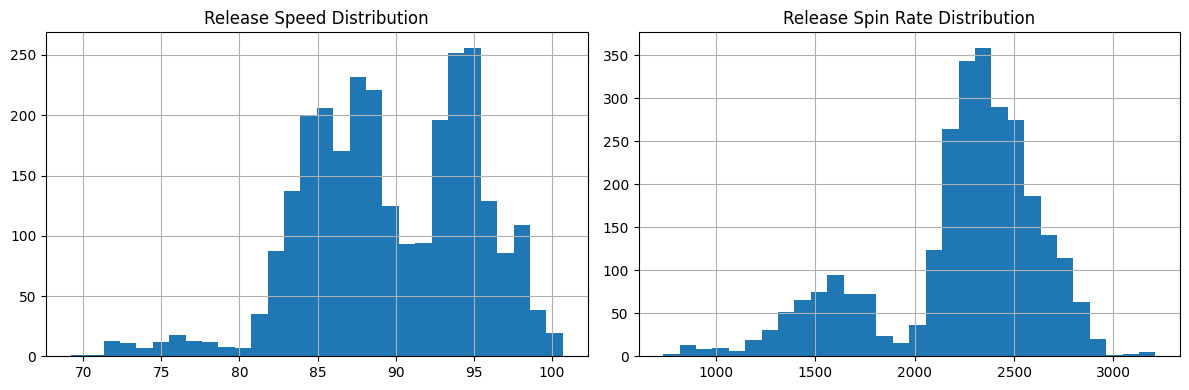

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bluejays_pitching['release_speed'].hist(bins=30, ax=axes[0])
axes[0].set_title('Release Speed Distribution')

bluejays_pitching['release_spin_rate'].hist(bins=30, ax=axes[1])
axes[1].set_title('Release Spin Rate Distribution')

plt.tight_layout()
plt.show()

count    2788.000000
mean       -0.000999
std         0.231175
min        -0.469000
25%        -0.062250
50%        -0.039000
75%         0.040000
max         2.632000
Name: delta_run_exp, dtype: float64


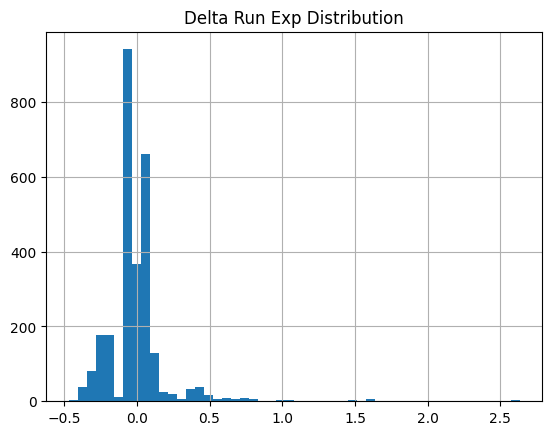

In [18]:
print(bluejays_pitching['delta_run_exp'].describe())
bluejays_pitching['delta_run_exp'].hist(bins=50)
plt.title('Delta Run Exp Distribution')
plt.show()

In [19]:
bluejays_pitching.groupby(['game_pk', 'pitcher'])['cumulative_pitches'].max().describe()

count    101.000000
mean      27.603960
std       25.275316
min        2.000000
25%       13.000000
50%       17.000000
75%       26.000000
max      104.000000
Name: cumulative_pitches, dtype: float64

In [20]:
bluejays_pitching['inning'].value_counts().sort_index()

inning
1     301
2     280
3     303
4     258
5     252
6     311
7     330
8     298
9     280
10     46
11     28
12     12
13      8
14     27
15     14
16     11
17     23
18      6
Name: count, dtype: int64

Innings 10 on onwards will be dropped for Q1 EDA. 

Reason: Each game determines a winner if a team is leading by inning 9. Otherwise, it goes to overtime and the `cum_pitch_count` resets back to 1

In [21]:
bluejays_pitching.groupby('pitch_name')['release_speed'].mean().sort_values(ascending=False)

pitch_name
4-Seam Fastball    95.035966
Sinker             94.477241
Cutter             90.217857
Changeup           89.785827
Slider             87.294074
Knuckle Curve      86.620115
Split-Finger       85.098259
Sweeper            82.515267
Curveball          79.220588
Name: release_speed, dtype: float64

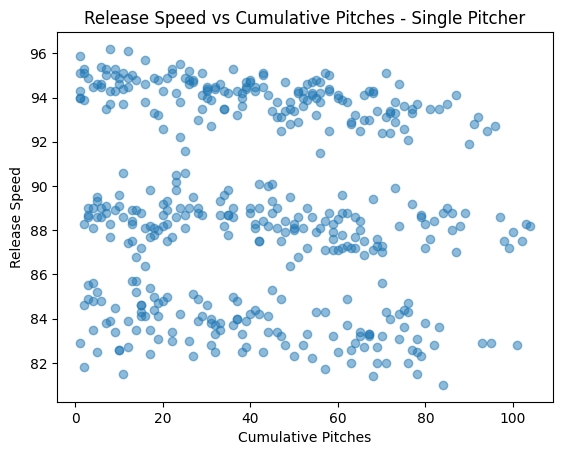

In [22]:
one_pitcher = bluejays_pitching[
    bluejays_pitching['pitcher'] == bluejays_pitching['pitcher'].value_counts().index[0]
]
plt.scatter(one_pitcher['cumulative_pitches'], one_pitcher['release_speed'], alpha=0.5)
plt.title('Release Speed vs Cumulative Pitches - Single Pitcher')
plt.xlabel('Cumulative Pitches')
plt.ylabel('Release Speed')
plt.show()